# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [9]:
# write your answer here
import pandas as pd
import matplotlib as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx
df = pd.read_csv("bread_basket.csv")
df.head()


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [10]:
# write your answer here
df.dtypes

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [11]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

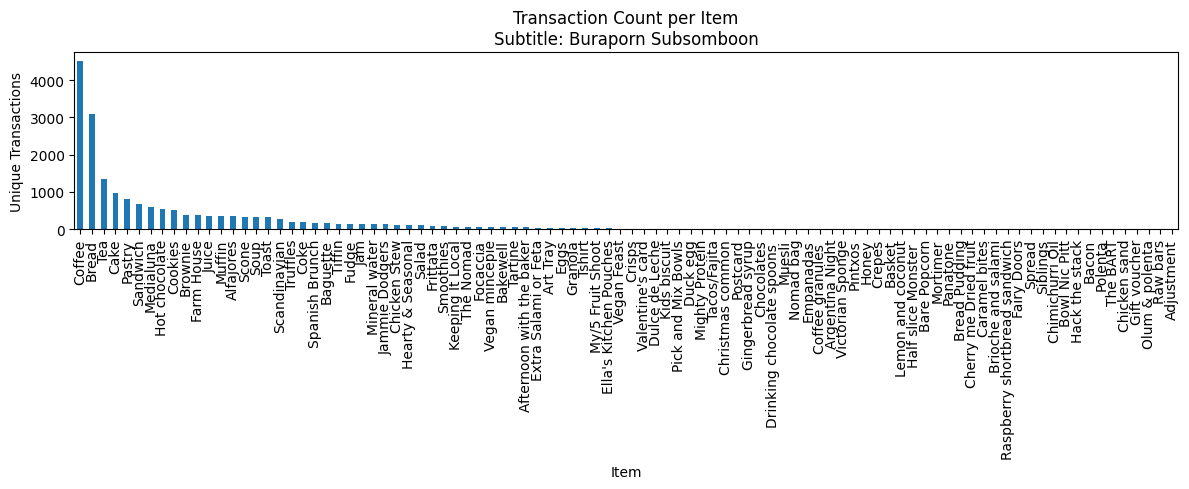

In [13]:
# c) Bar plot of transaction counts per item
import matplotlib.pyplot as plt
subtitle = "Buraporn Subsomboon"
item_counts = (
    df.groupby("item")["transaction"]
      .nunique()
      .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [27]:
# write your answer here
targets = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

counts = (
    df[df["item"].isin(targets)]
      .groupby("item")["transaction"]
      .nunique()
      .reindex(targets)
)

counts

item
Coffee          4528
Tea             1350
Alfajores        344
Juice            365
Chicken Stew     123
Name: transaction, dtype: int64

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [46]:
# write your answer here
basket = (
    df.assign(present=1)
      .pivot_table(index="transaction",
                   columns="item",
                   values="present",
                   aggfunc="max",
                   fill_value=0)
      .astype(bool)
)

min_support = 0.01

frequent_itemsets = fpgrowth(basket, min_support=0.01, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False)

,support,itemsets
6,0.478394,(Coffee)
0,0.327205,(Bread)
9,0.142631,(Tea)
16,0.103856,(Cake)
30,0.090016,"(Bread, Coffee)"
...,...,...
14,0.010565,(Hearty & Seasonal)
26,0.010460,(Salad)
55,0.010354,"(Bread, Alfajores)"
50,0.010037,"(Cake, Bread, Coffee)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [47]:
# write your answer here
from mlxtend.frequent_patterns import association_rules
for t in [0.1, 0.15, 0.2, 0.25]:
    r = association_rules(frequent_itemsets, metric="confidence", min_threshold=t)
    print(f"threshold={t} → {len(r)} rules")
min_threshold = 0.1 

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=min_threshold
)
rules = rules.sort_values(["lift", "confidence"], ascending=False)
rules

threshold=0.1 → 44 rules
threshold=0.15 → 37 rules
threshold=0.2 → 31 rules
threshold=0.25 → 24 rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
28,"(Tea, Coffee)",(Cake),0.049868,0.103856,0.010037,0.201271,1.937977,1.0,0.004858,1.121962,0.509401,0.069853,0.108705,0.148957
5,(Hot chocolate),(Cake),0.058320,0.103856,0.011410,0.195652,1.883874,1.0,0.005354,1.114125,0.498236,0.075683,0.102434,0.152760
4,(Cake),(Hot chocolate),0.103856,0.058320,0.011410,0.109868,1.883874,1.0,0.005354,1.057910,0.523553,0.075683,0.054740,0.152760
24,(Tea),(Cake),0.142631,0.103856,0.023772,0.166667,1.604781,1.0,0.008959,1.075372,0.439556,0.106736,0.070090,0.197779
25,(Cake),(Tea),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779
41,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
14,(Pastry),"(Bread, Coffee)",0.086107,0.090016,0.011199,0.130061,1.444872,1.0,0.003448,1.046033,0.336907,0.067905,0.044007,0.127237
13,"(Bread, Coffee)",(Pastry),0.090016,0.086107,0.011199,0.124413,1.444872,1.0,0.003448,1.043749,0.338354,0.067905,0.041916,0.127237
33,(Sandwich),(Tea),0.071844,0.142631,0.014369,0.200000,1.402222,1.0,0.004122,1.071712,0.309050,0.071806,0.066913,0.150370
34,(Tea),(Sandwich),0.142631,0.071844,0.014369,0.100741,1.402222,1.0,0.004122,1.032134,0.334566,0.071806,0.031134,0.150370


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)
 - Support: 0.010037 or around 1.00% of all transactions contain Coffee, Cake, and Bread together
 - Confidence: 0.183398 or around 18.34% If the customer has Coffee and Cake, there is 18.34% chance they will also buy bread
 - Lift: 0.5605 and is less than one. A negative association, meaning Bread is actually less likely to be purchased when Coffee and Cake       are bought together compared to its overall purchase rate.
     - Practical Meaning: Coffee and Cake do not positively drive Bread purchases, and bundling them may not be an effective cross-selling         strategy.

In [50]:
target_rule = rules[
    (rules["antecedents"] == frozenset(["Coffee", "Cake"])) &
    (rules["consequents"] == frozenset(["Bread"]))
]

target_rule[["support", "confidence", "lift"]]

,support,confidence,lift
31,0.010037,0.183398,0.560497


Number of rules found for graph: 15


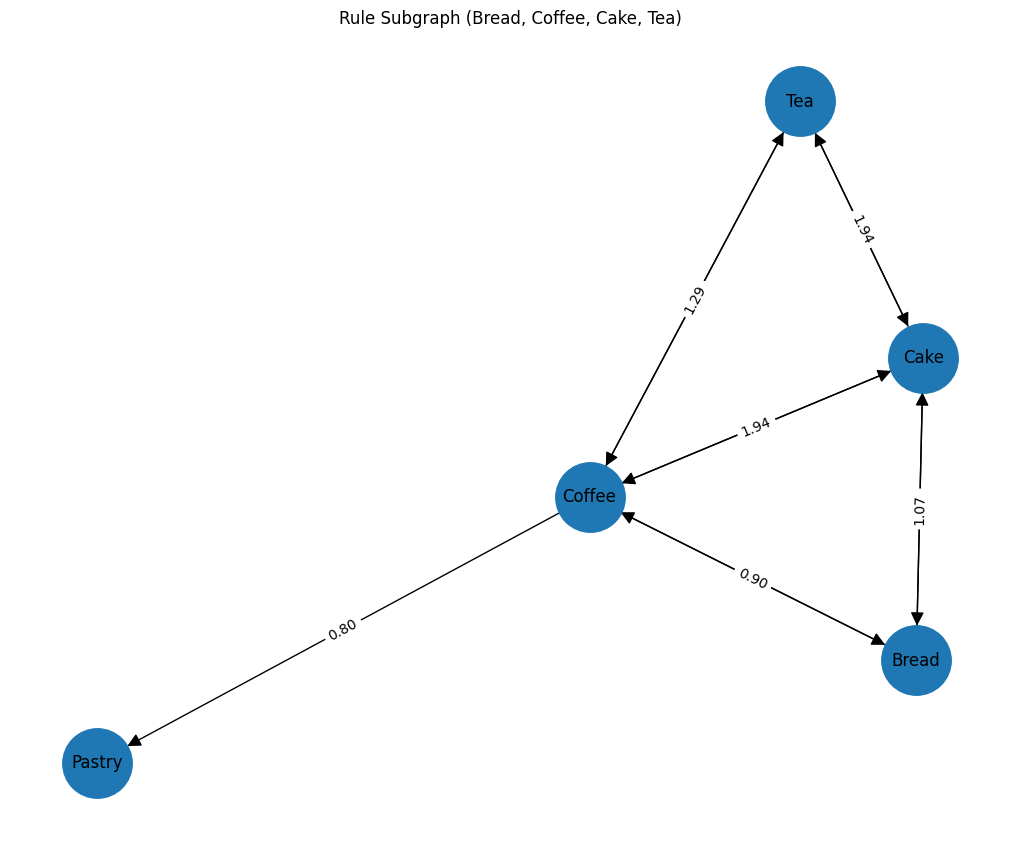

In [55]:
import networkx as nx
import matplotlib.pyplot as plt

target_items = {'bread', 'coffee', 'cake', 'tea'}

sub_rules = rules[
    rules['antecedents'].apply(lambda x: any(i.lower() in target_items for i in x)) &
    rules['consequents'].apply(lambda x: any(i.lower() in target_items for i in x))
].sort_values("lift", ascending=False).head(15)

print(f"Number of rules found for graph: {len(sub_rules)}")

G = nx.DiGraph()

for _, row in sub_rules.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            if G.has_edge(ant, cons):
                G[ant][cons]["lift"] = max(G[ant][cons]["lift"], float(row["lift"]))
            else:
                G.add_edge(ant, cons, lift=float(row["lift"]))

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=7)

nx.draw(G, pos, with_labels=True, node_size=2500, arrowsize=20)

edge_labels = {(u, v): f"{d['lift']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title("Rule Subgraph (Bread, Coffee, Cake, Tea)")
plt.axis("off")
plt.show()